# DQI with Gauss-Jordan Elimination
DQI can be used with any decoding strategy - this one is the GJ elimination strategy which is very much identical to what you might have learnt in linear algebra. 

In [1]:
import os, sys

import numpy as np
import warnings
import pprint
pp = pprint.PrettyPrinter(depth=4)

# Qiskit imports for simulation and circuit construction
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.quantum_info import Statevector, partial_trace

# Custom module imports - updated to use new structure
from src.dqi.qiskit.initialization.state_preparation.gates import UnaryAmplitudeEncoding
from src.dqi.qiskit.initialization.calculate_w import get_optimal_w
from src.dqi.qiskit.dicke_state_preparation.gates import UnkGate
from src.dqi.qiskit.decoding.gates import GJEGate
from src.dqi.utils.solver import brute_force_max
from src.dqi.utils.visualize import plot_results_union_plotly
from src.dqi.utils.counts import post_selection_counts, combine_counts

warnings.filterwarnings("ignore")

## The objectuive and its landscape

Here we prepare a simple matrix. It represents a XOR_SAT problem. The matrix represents a system of linear equations over boolean algebra. 

The columns as written (the double transpose is there so that it is easier to explain) are variables (if it is a grid, these would be the grid points, of which there are 6).  
The rows are the constraints. 1s mean that the variable is a part of the equation. For the below matrix this is telling the quantum computer (just showing the first two):

Row 0 [1, 0, 0, 0, 0, 1]: Variable 0 and Variable 1 are linked. (x_0⊕x_5=v_0) 

Row 1 [1, 1, 0, 0, 0, 0]: Variable 0 and Variable 4 are linked. (x_1⊕x_2=v_1)

The whole matrix represents a simple loop graph 

       x_0
      /   \
    x_1   x_5
     |     |
    x_2   x_4
      \   /
       x_3

and the ideal solution would be alternating 0s and 1s, since we want the answer to result in all the variables being one as defined in `v= np.ones(B.shape[0])`.

Remembering from the presentation, the obsective function is 
$$f(\mathbf{x})=\sum_{i=1}^{m}(-1)^{v_i+\mathbf{b_i}\cdot\mathbf{x}}=\sum_{i=1}^{m}f_i(\mathbf{x})$$
again, relating this to the matrix, b_i is the row of the matrix and it represents the number of satisfied minus unsatisfied equations. 

In [2]:
H = np.array([ #This here defines your problem, the rows are the equations and the columns are the variables. The 1s indicate which variables are in which equations.
        [1, 0, 0, 0, 0, 1],
        [1, 1, 0, 0, 0, 0],
        [0, 1, 1, 0, 0, 0],
        [0, 0, 1, 1, 0, 0],
        [0, 0, 0, 1, 1, 0],
        [0, 0, 0, 0, 1, 1]
    ]).T

B = H.T
v = np.ones(B.shape[0])
v

array([1., 1., 1., 1., 1., 1.])

As you can see below, there are indeed two peaks

In [3]:
brute_force_results = brute_force_max(B, v)
plot_results_union_plotly(
    brute_force_results,
    {},
    plot_name="Objective Values Landscape",
    spline_smoothing=1.3
)


# Building the DQI algorithm

We need to encode this as $|P(f)\rangle=\sum_{\mathbf{x}} P(f(\mathbf{x}))|\mathbf{x}\rangle,$  according to DQI since a straightforward encoding as $\sum_{\mathbf{x}} f(\mathbf{x})|\mathbf{x}\rangle$ requires obtaining x strings with high values of f(x) with high probability, this is in theory possible, but it hasn't yielded good results even though it was a common approach for a while. Remember from the presentation that P is a polynomial of high degree. 

Since the objective function has a sparse Hadamard spectrum (defined by $m$ of $2^n$ possible answers being non-zero in f(x), where m is on the order of n). This means if you take the QFT (which in this case is simplified to the Hadamard transform $H^{\otimes n}|\mathbf{x}\rangle = \frac{1}{\sqrt{2^n}}\sum_{\mathbf{y}\in \{0,1\}^n}(-1)^{\mathbf{x}\cdot\mathbf{y}}|\mathbf{y}\rangle.$) you will have few peaks of high probability. 

Taking the hadamard transform of the transformed equationof DQI looks like this:
$$\begin{split}\sum_{k=0}^{\ell} \frac{w_k}{\sqrt{\binom{m}{k}}} \sum_{\substack{\mathbf{y}\\|\mathbf{y}|=k}} (-1)^{\mathbf{v}\cdot\mathbf{y}} |B^T \mathbf{y}\rangle,\end{split}$$ 

The coeficcients $w_k$ are specially chosen so that they form a Dicke state. The reason for this is in 8.1 of https://arxiv.org/abs/2408.08292 

now we prepare the Dicke state, which has several determenistic and efficient preparations, and here is one https://arxiv.org/abs/1904.07358v1 . This is done in the weight register and you can follow the code below:

# Step 1: Initialize weight coefficients
We prepare the weight register to make the state $\sum_{k=0}^{\ell} w_k|k\rangle$.

In [4]:
n = len(B[0])  # Number of qubits corresponding to constraints
m, p, r, ell = len(B), 2, 1, 2  # Additional parameters for state preparation

# Compute optimal weight values for the initialization
w = get_optimal_w(m, ell, p, r)
 
print("Optimal W_k value: ", w.tolist())

Optimal W_k value:  [-0.4330127018922193, -0.7071067811865475, -0.5590169943749475, 0.0]


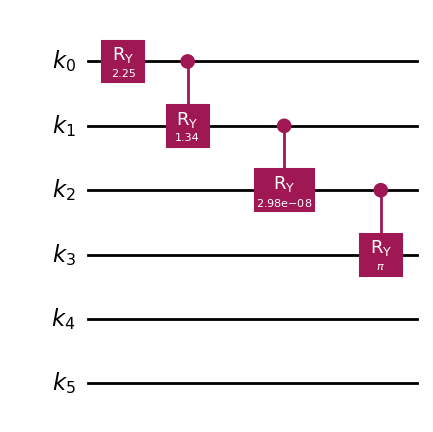

In [5]:
# Build the initialization circuit using Weighted Unary Encoding
init_qregs = QuantumRegister(m, name='k')
initialize_circuit = QuantumCircuit(init_qregs)
WUE_Gate = UnaryAmplitudeEncoding(num_bit=m, weights=w)
initialize_circuit.append(WUE_Gate, range(m))
display(initialize_circuit.decompose().draw('mpl'))
show_sv = False
if show_sv:
    display(Statevector(initialize_circuit).draw('latex'))


# Step 2. Dicke state preparation
We then prepare the Dicke state in the error register which is conditioned on the value $k$ defined in the weight register
$$\begin{split}\sum_{k=0}^{\ell} w_k|k\rangle \frac{1}{\sqrt{\binom{m}{k}}}\sum_{\substack{\mathbf{y}\\|\mathbf{y}|=k}} |\mathbf{y}\rangle.\end{split}$$ 
This is a Dicke state with $k$ excitations on $m$ qubtis which is denoted $|D^{m}_{k}\rangle$. They are uniform superpositions of all bit strings of a given Hamming weight. There is a construction (denoted SCS) which are a Split and Cyclic shift unitary that is used, which you can see decomposed. By removing the amount of `deocmpose()` instructions you can see it at different levels of abstraction. 

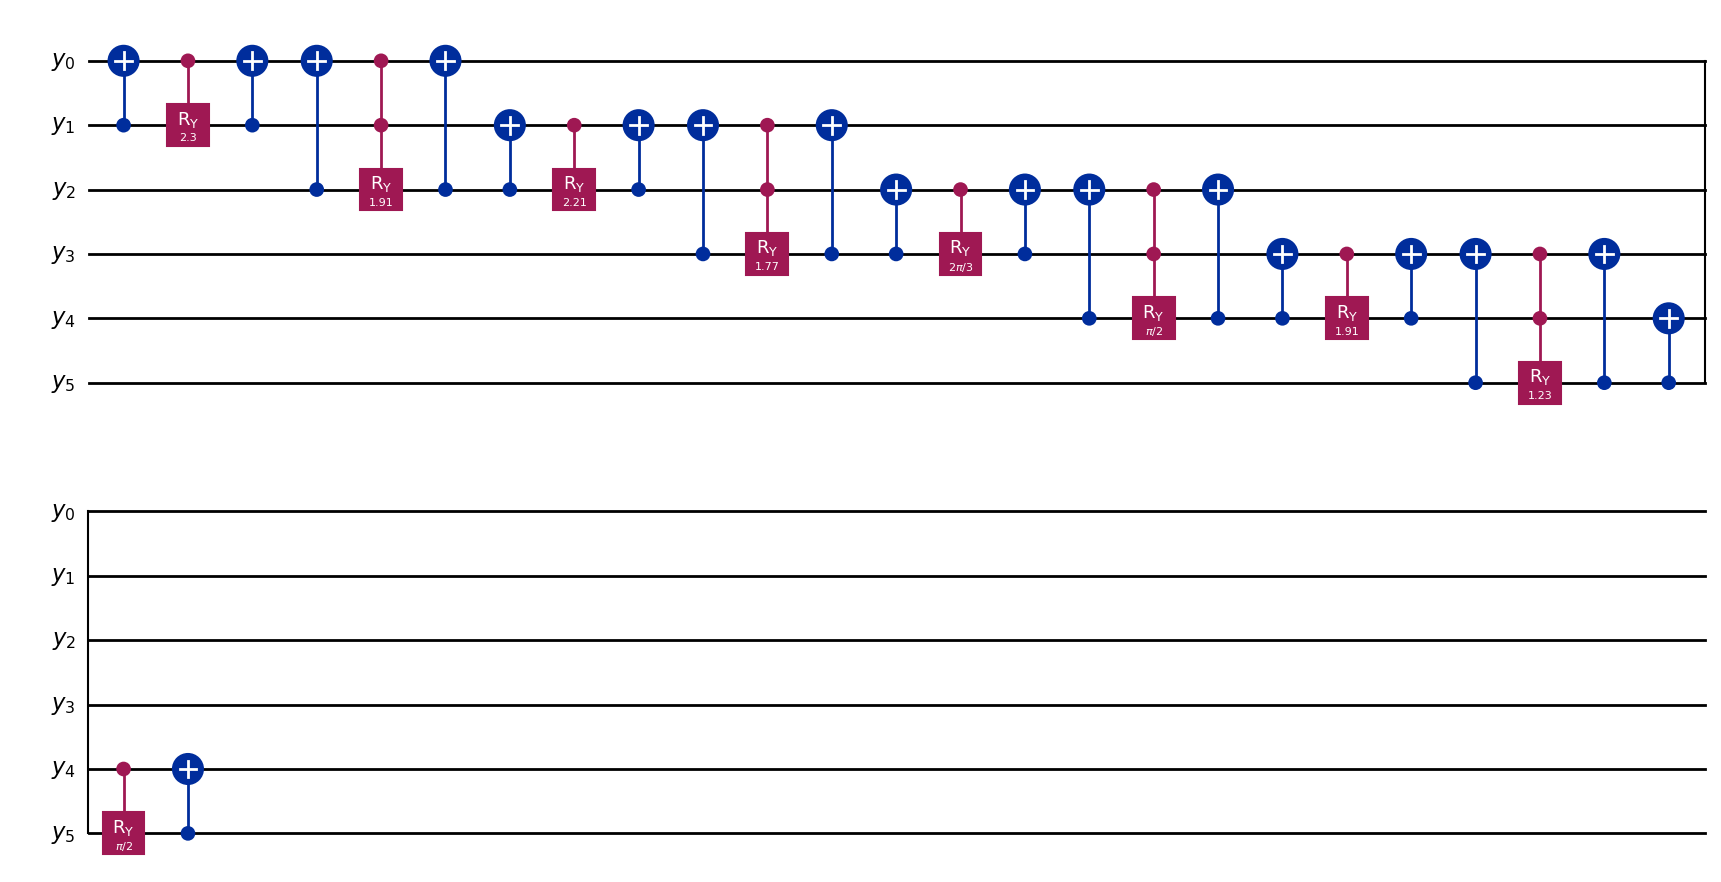

In [6]:
# Prepare the Dicke state circuit
dicke_qregs = QuantumRegister(m, name='y')
dicke_circuit = QuantumCircuit(dicke_qregs)
max_errors = int(np.nonzero(w)[0][-1]) if np.any(w) else 0
dicke_circuit.append(UnkGate(m, max_errors), range(m))
display(dicke_circuit.decompose(reps=3).draw('mpl'))

We can then combine the circuit, and prepare the full DQI circuit in which we will put the rest of the gates as follows. 

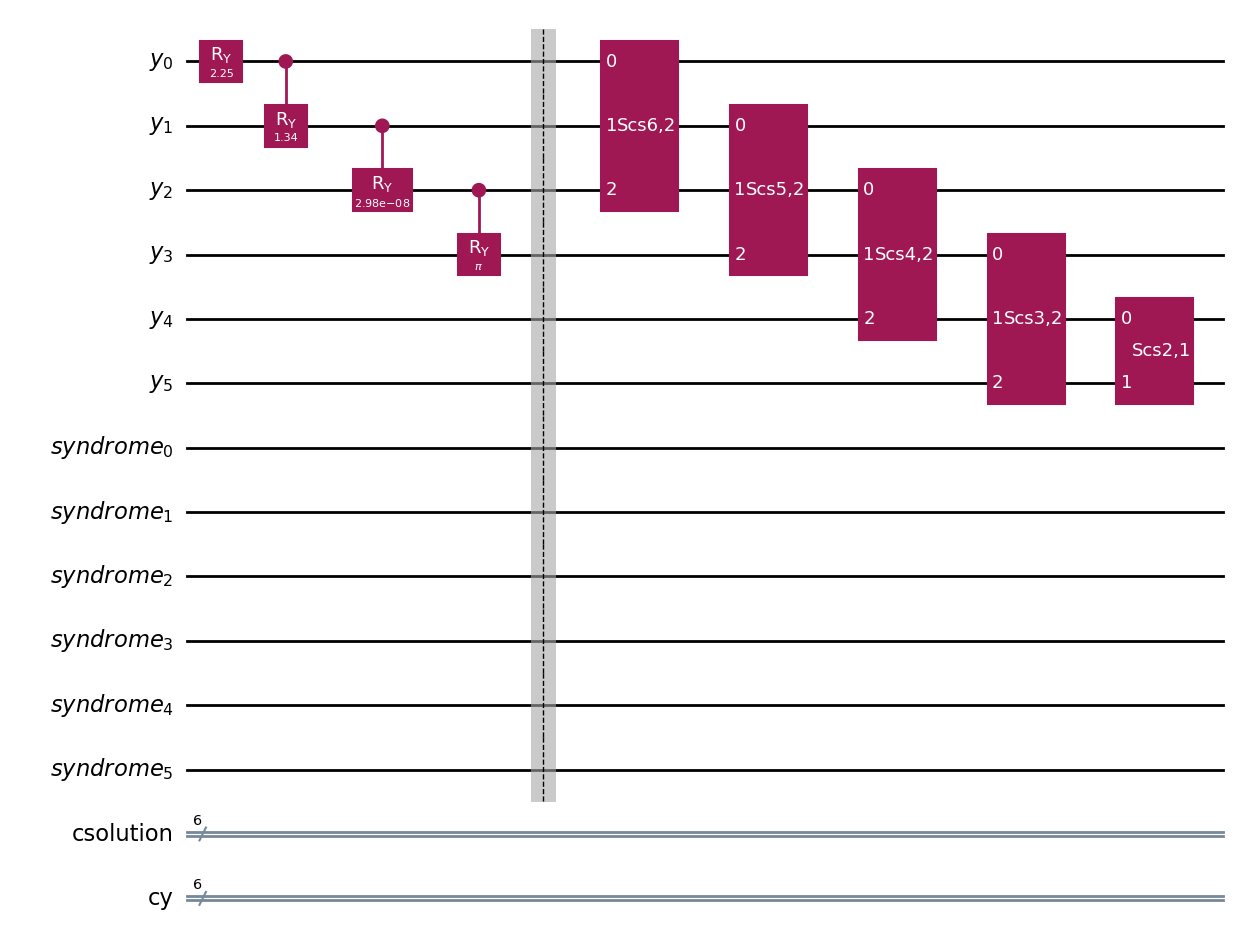

In [7]:
# Create registers for syndrome and measurement
dicke_qregs = QuantumRegister(m, name='y') 
dicke_cregs = ClassicalRegister(m, name='cy')
syndrome_qregs = QuantumRegister(n, name='syndrome')
syndrome_cregs = ClassicalRegister(syndrome_qregs.size, name='csolution')
# Build the DQI circuit by composing initialization and Dicke circuits
dqi_circuit = QuantumCircuit(dicke_qregs, syndrome_qregs, syndrome_cregs, dicke_cregs)
dqi_circuit.compose(initialize_circuit, inplace=True)
dqi_circuit.barrier()
dqi_circuit.compose(dicke_circuit, inplace=True)
display(dqi_circuit.decompose().draw('mpl'))
if show_sv:
    display(Statevector(dqi_circuit).draw('latex'))

# Encode the constraint vector
To encode what we want the answer to be, we flip the phase of all the 1's in our $v$ vector (which in this case is all of them), these will be added to the y register. This imparts the part of the equation that looks like $(-1)^{\mathbf{v}\cdot\mathbf{y}}$ 

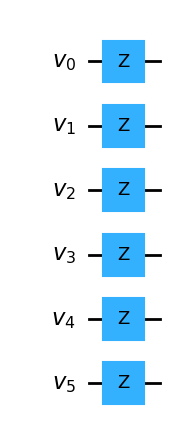

In [8]:
# Apply phase flip operations based on v
v_phase_qregs = QuantumRegister(m, name='v')
v_phase_flip_circuit = QuantumCircuit(v_phase_qregs)
for i in range(len(v)):
    if v[i] == 1:
        v_phase_flip_circuit.z(i)
display(v_phase_flip_circuit.draw('mpl'))

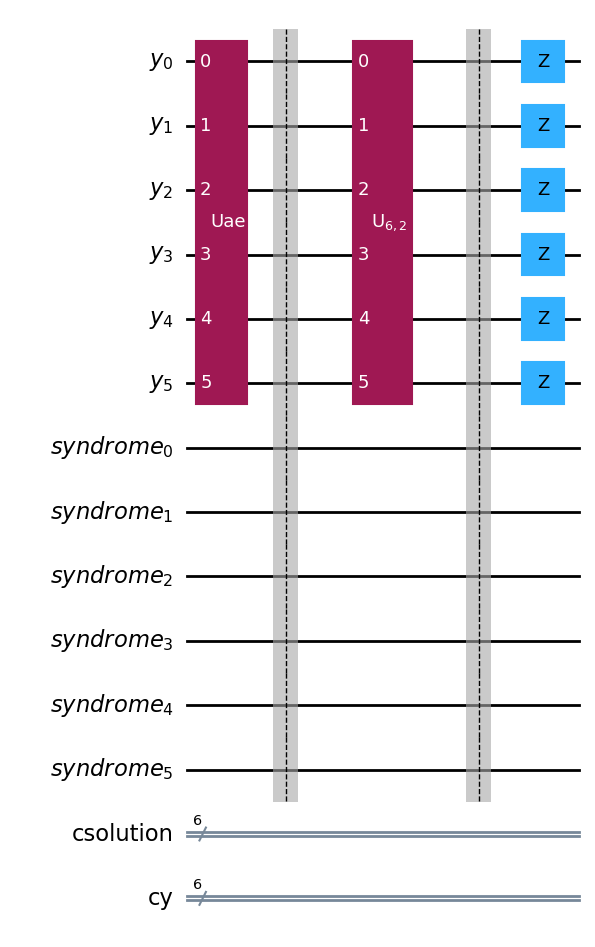

In [9]:
dqi_circuit.barrier()
dqi_circuit.compose(v_phase_flip_circuit, qubits=range(m), inplace=True)
display(dqi_circuit.draw('mpl'))

# Encoding our constraint matrix B
The constraint matrix/code $B^T \mathbf{y}$ needs to be computed into the syndrome register. Since the matrix and vector are binary this can be easily done by CNOT gates with controls on the error register (y) and targets in the syndrome measurement. These are added for every time $B_{ij}^T=1$ 

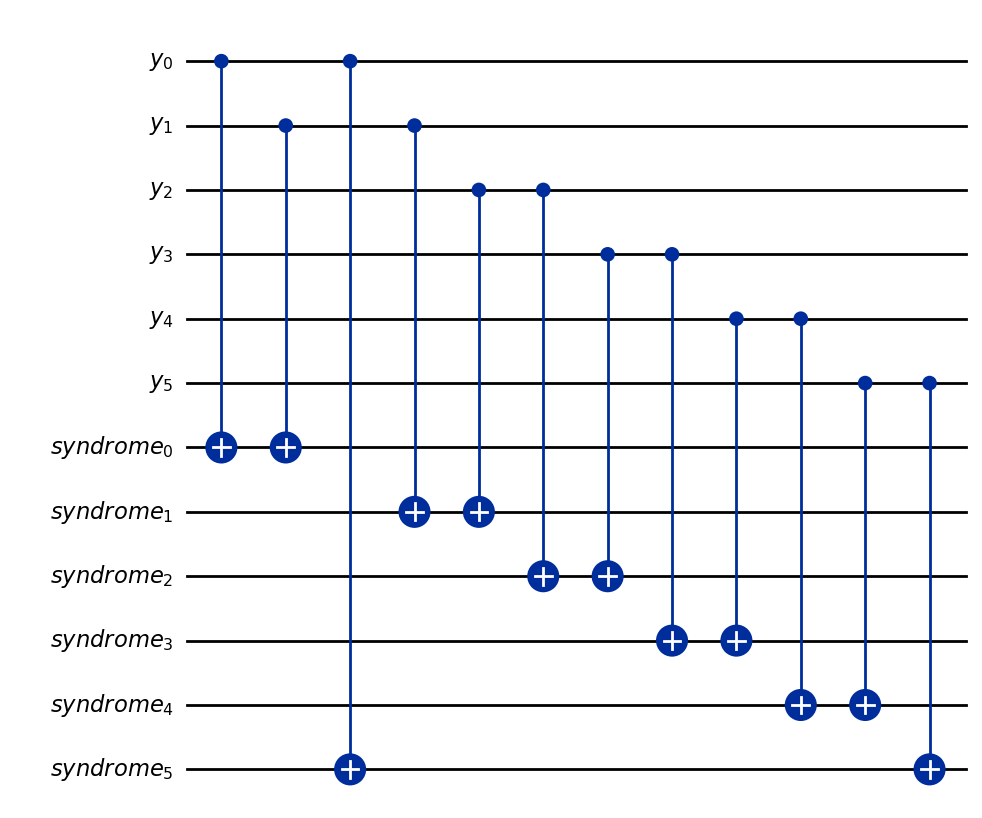

In [10]:
# Encode the constraint matrix B using CNOT gates - also why the constraint matrix can only have 1s
B_circuit = QuantumCircuit(dicke_qregs, syndrome_qregs)
for i in range(n):
    for j in range(m):
        if B.T[i][j] == 1:
            B_circuit.cx(j, m+i)
display(B_circuit.draw('mpl'))

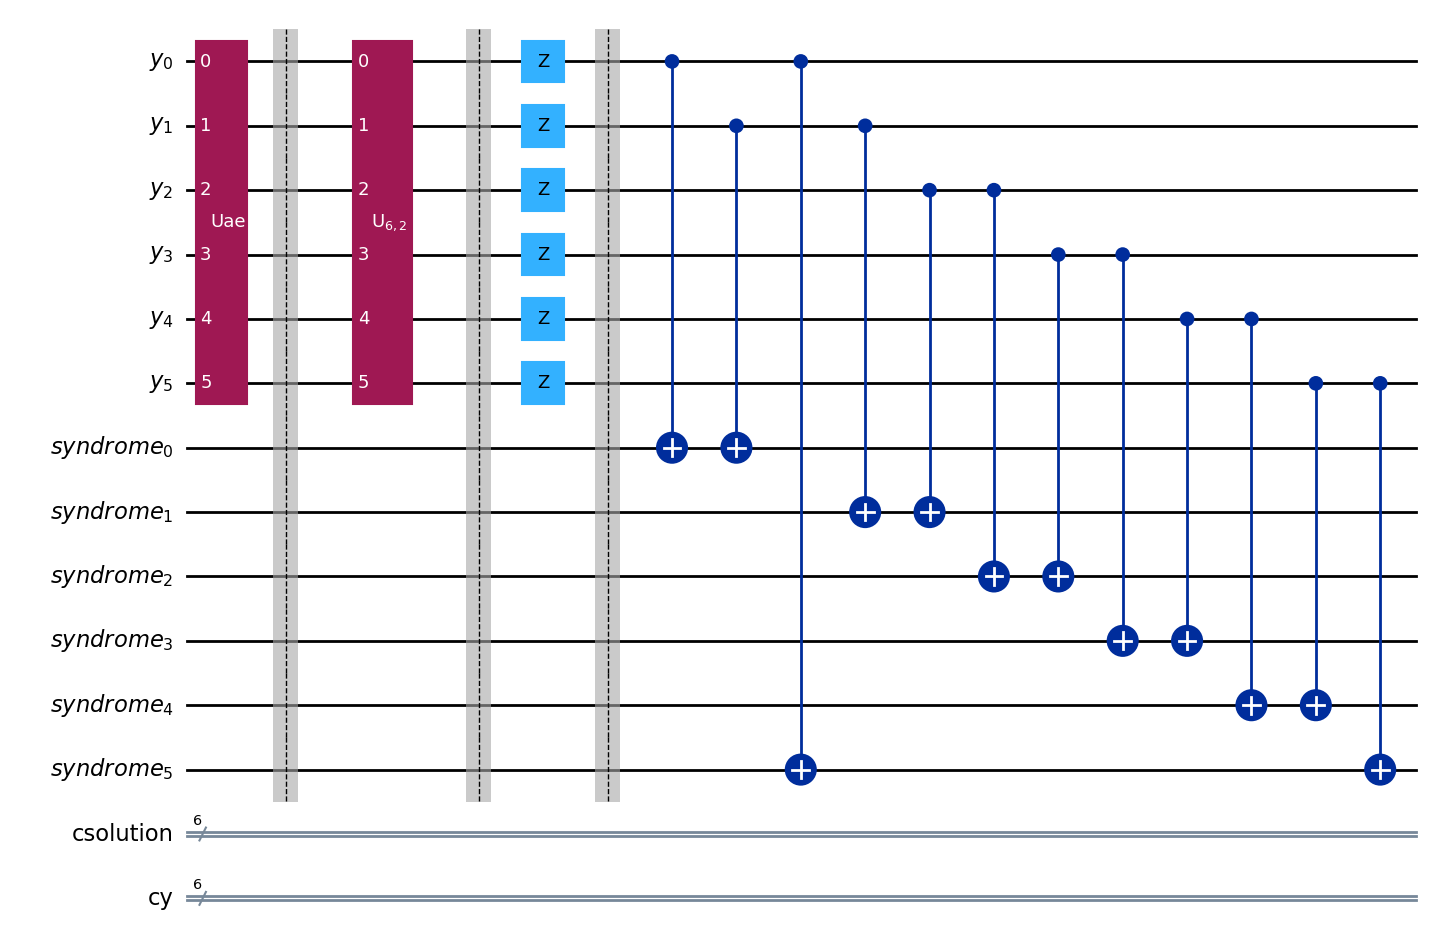

In [11]:
dqi_circuit.barrier()
dqi_circuit.compose(B_circuit, qubits=list(range(m+n)), inplace=True)
dqi_circuit.draw('mpl')

# Decoding 
This is the most computationally taxing part of the algorithm (assuming you are not considering running the simulation, since that should be done on a QC). Here the simplest option is to write a function that looks up all possible errors, but we can also write a decoding part of the circuit. Over here a Gauss-Jordan elimination strategy is shown, but there is a notebook that has belief propagation applied instead. 

The thing that this part of the algorithm attempts to solve is that we want to uncompute the error register y using what we get from the syndrome register $B^Ty$. If this was a square matrix (like in this example), this woudl be easy, but it is not always the case, so sometimes we must solve an underdetermined system of equations with some constraint - generally $|y|<l$ determined by the Hamming weights of $y$ - this is the syndrome decoding problem and $B^T$ is the parity check matrix. 

In [12]:
dqi_circuit.barrier()
if n > m:
    decoding_circuit = QuantumCircuit(syndrome_qregs, name="GJE")
    GJE_gate = GJEGate(B.T)
    decoding_circuit.append(GJE_gate, range(n))
    dqi_circuit.append(decoding_circuit, range(m, m+n))
    for i in range(m):
        dqi_circuit.cx(syndrome_qregs[i], dicke_qregs[i])
    dqi_circuit.append(decoding_circuit.inverse(), range(m, m+n))
else:
    # For n <= m case, we only apply inverse GJE before CNOTs
    decoding_circuit = QuantumCircuit(dicke_qregs[:n], name="GJE")
    GJE_gate = GJEGate(B.T)
    decoding_circuit.append(GJE_gate, range(n))
    dqi_circuit.append(decoding_circuit.inverse(), range(n))
    for i in range(n):
        dqi_circuit.cx(syndrome_qregs[i], dicke_qregs[i])
    

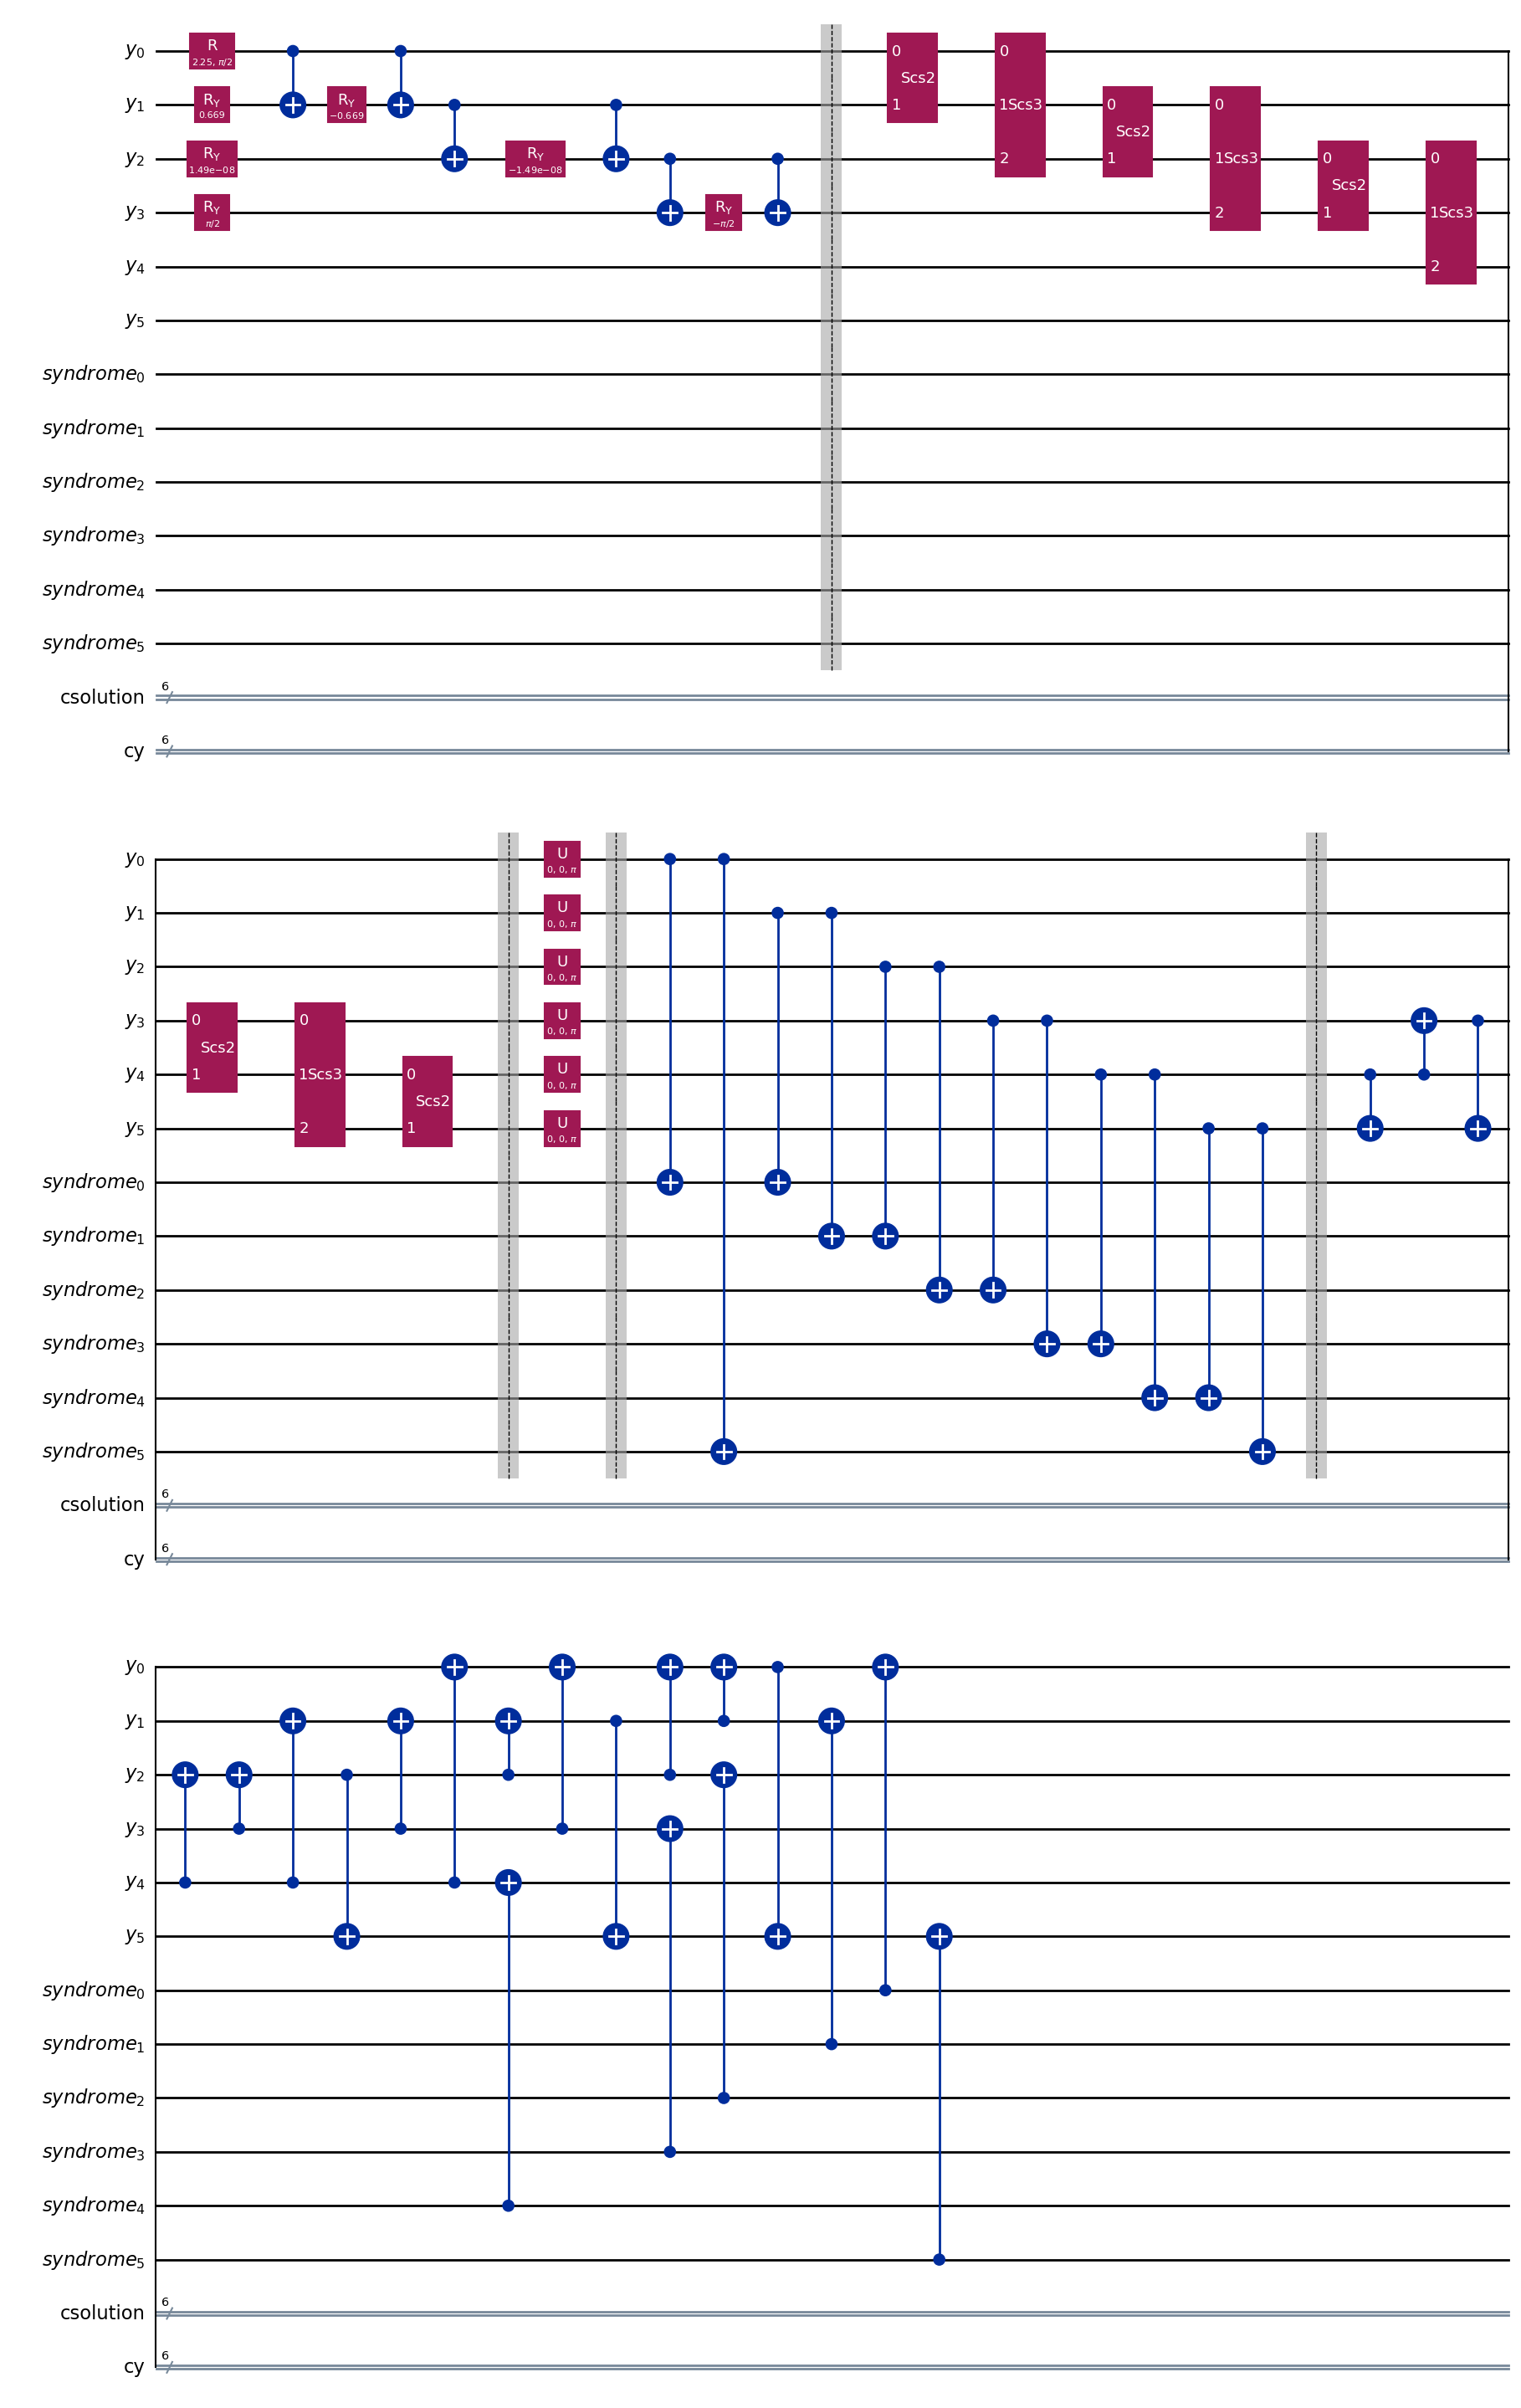

In [13]:
dqi_circuit.decompose().decompose().draw('mpl')

# Final step
Finally we apply a Hadamard transform to the syndrome register which transforms the state into $|P(f)\rangle=\sum_{\mathbf{x}} P(f(\mathbf{x}))|\mathbf{x}\rangle$. Now we add measurements as well. 


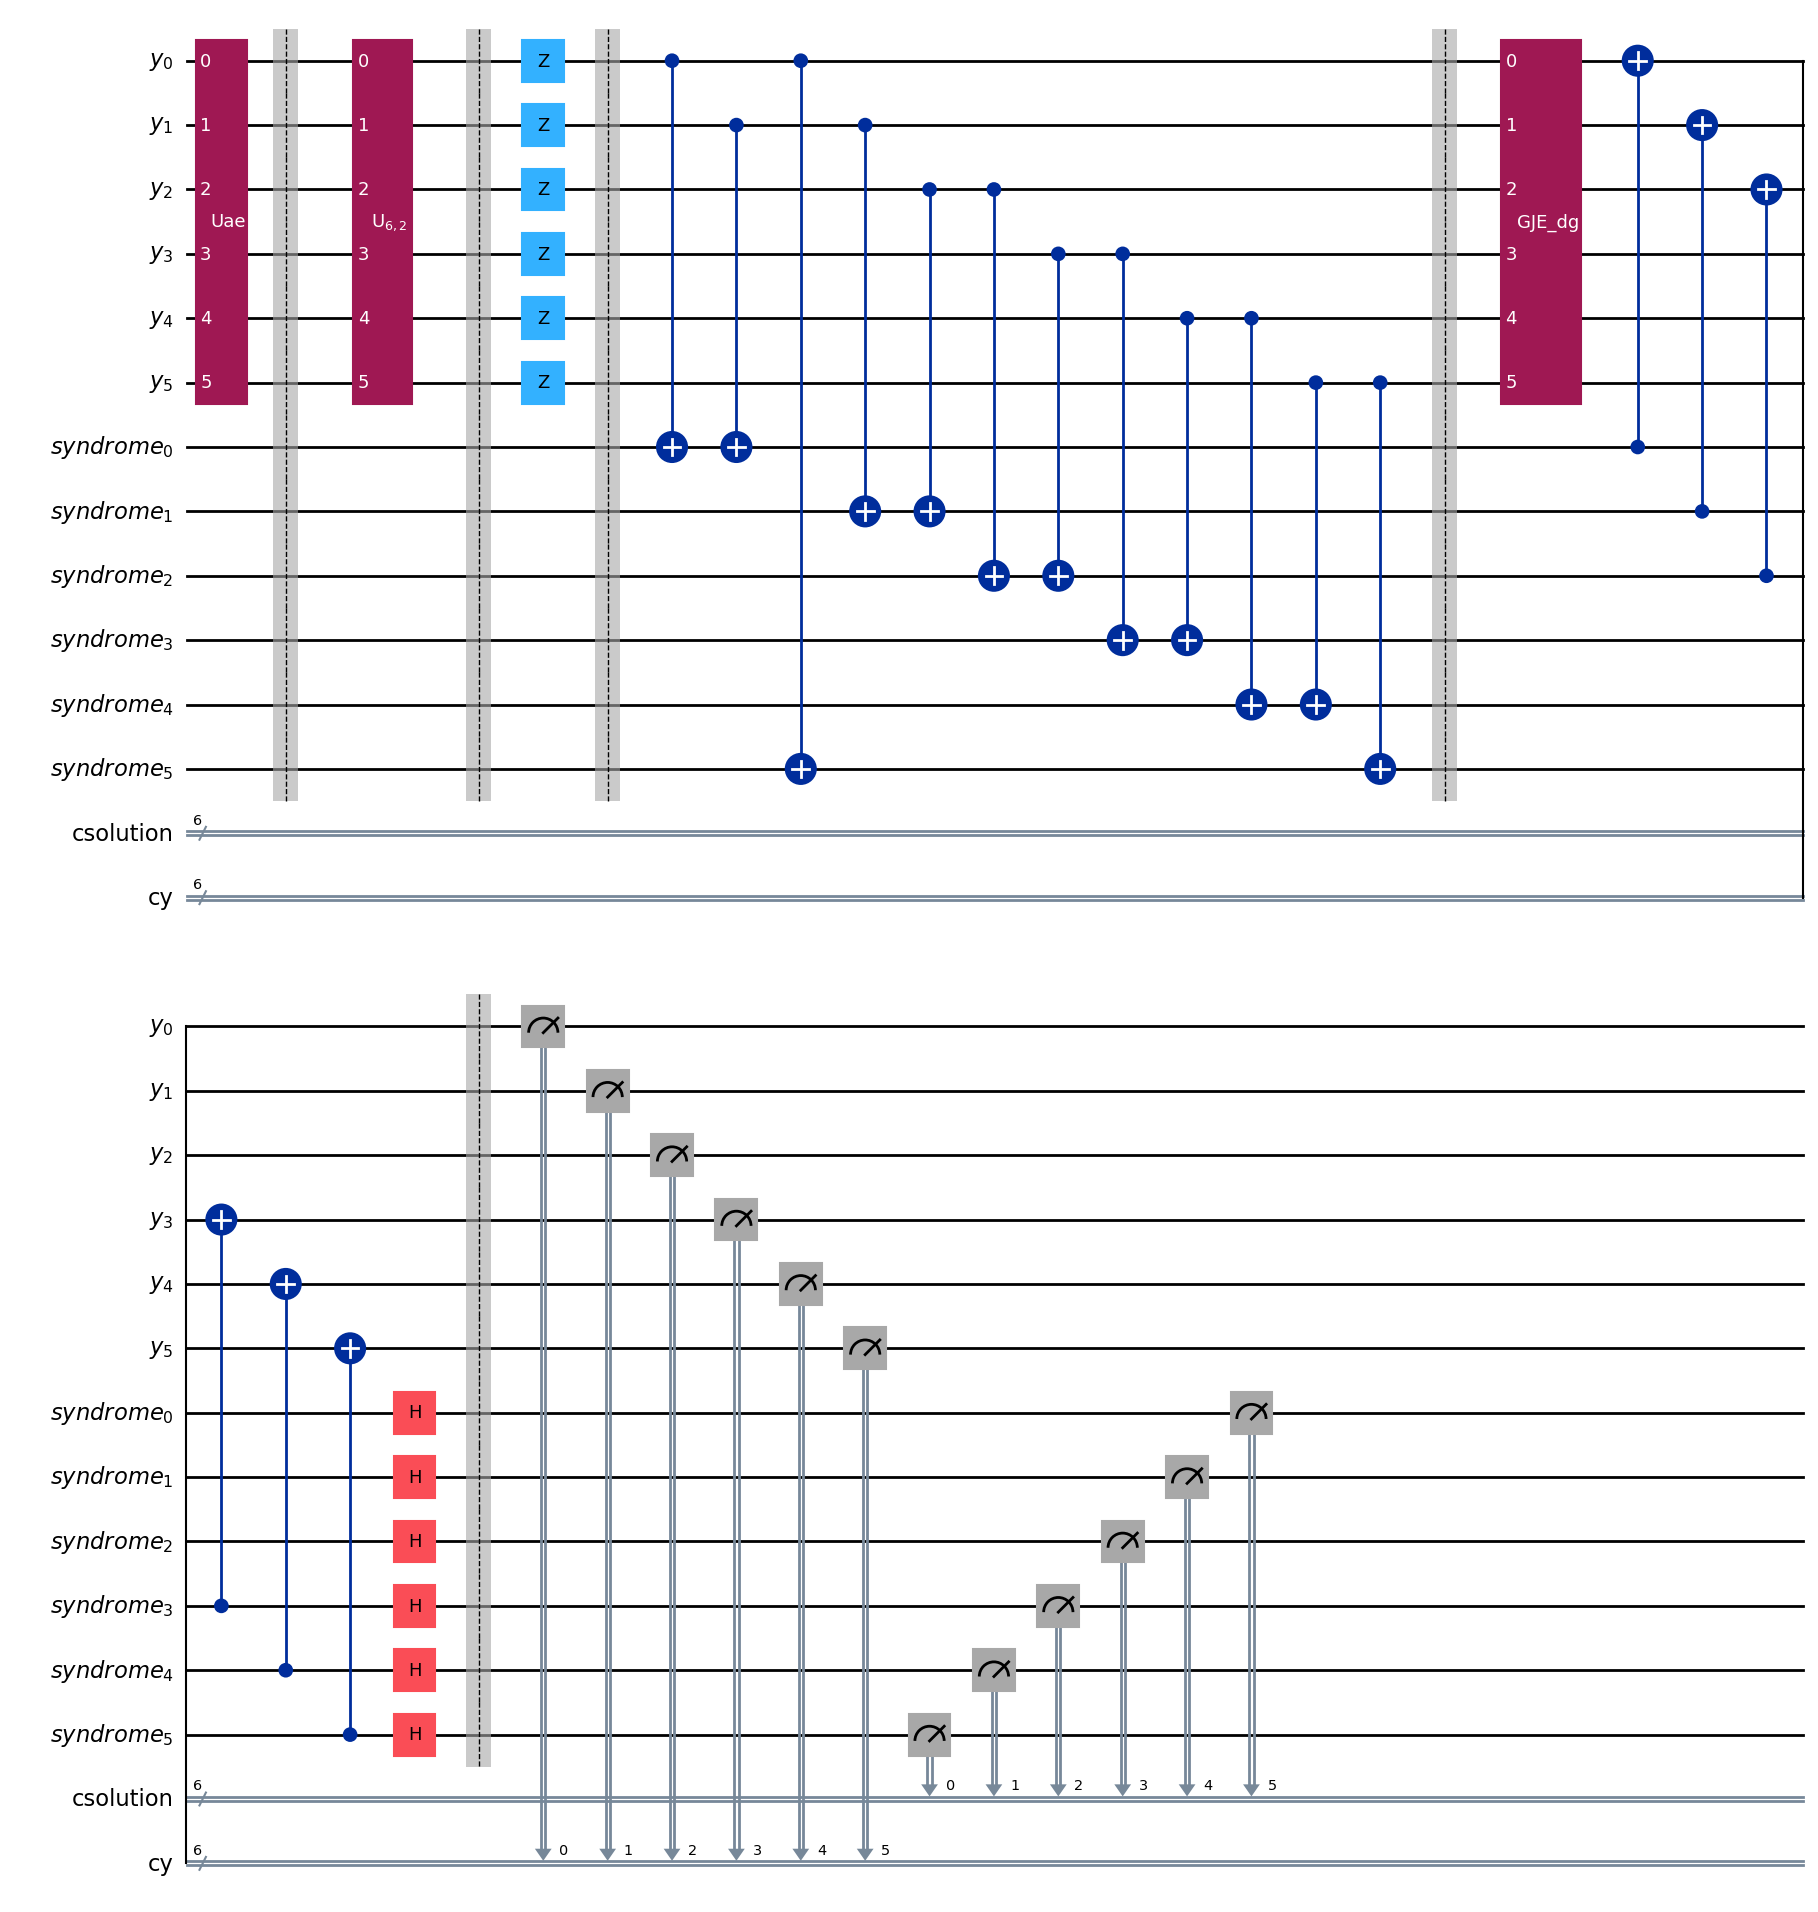

In [14]:
for i in range(n):
    dqi_circuit.h(m+i)
    
# Measurement
dqi_circuit.barrier()
dqi_circuit.measure(dicke_qregs, dicke_cregs)
dqi_circuit.measure(syndrome_qregs[::-1], syndrome_cregs)
dqi_circuit.draw('mpl')

# Sampling the results
We run this many times and count our results. The only useful results for us are those where the block of the y register results are all 0, and the syndrome register is the answer. The higher the probability of the answer the more constraints it satisfies, as clearly shown in the dictionary and following visualizations. 

In [15]:
simulator = AerSimulator()
transpiled_circuit = transpile(dqi_circuit, backend=simulator)
result = simulator.run(transpiled_circuit, shots=100000).result()
counts = result.get_counts(dqi_circuit)
sorted_counts = {k: v for k, v in sorted(counts.items(), key=lambda item: item[1], reverse=True)}
sorted_counts

{'000000 010101': 17318,
 '000000 101010': 17204,
 '000000 110100': 3993,
 '000000 010011': 3982,
 '000000 100100': 3951,
 '000000 101011': 3930,
 '000000 001011': 3895,
 '000000 010100': 3891,
 '000000 101000': 3890,
 '000000 101100': 3890,
 '000000 010111': 3847,
 '000000 011011': 3807,
 '010000 010101': 1607,
 '010000 101010': 1591,
 '010000 011011': 873,
 '010000 101011': 858,
 '010000 001011': 857,
 '010000 100100': 857,
 '010000 101100': 846,
 '010000 010111': 835,
 '010000 010011': 807,
 '010000 110100': 792,
 '010000 010100': 783,
 '010000 101000': 780,
 '000000 011101': 329,
 '000000 011001': 314,
 '000000 111010': 313,
 '010000 000000': 311,
 '010000 100101': 309,
 '000000 010010': 308,
 '000000 001101': 308,
 '000000 100110': 308,
 '000000 111111': 308,
 '010000 001001': 306,
 '010000 001101': 306,
 '010000 011010': 306,
 '010000 010010': 305,
 '010000 101001': 303,
 '000000 101101': 300,
 '010000 000101': 298,
 '010000 110110': 298,
 '010000 110010': 296,
 '000000 110010': 

In [16]:
plot_results_union_plotly(
    brute_force_results,
    counts,
    plot_name="Comparison of DQI Results with True Objective Values",
    spline_smoothing=1.3
)


In [17]:
counts_filtered = post_selection_counts(counts)
plot_results_union_plotly(
    brute_force_results,
    counts_filtered,
    plot_name="Comparison of DQI Results with True Objective Values (Post-selected on |0⟩)",
    spline_smoothing=1.3
)


In [18]:
combined_counts = combine_counts(counts)
plot_results_union_plotly(
    brute_force_results,
    combined_counts,
    plot_name="Comparison of DQI Result and True Objective Values (Combined)",
    spline_smoothing=1.3
)


# Using this in a pseudo wavefunction collapse like algorithm! 

Let us begin by defining a simple function. WFC in essence is a constraint solving algorithm using a special local solution technique. However here we will jsut construct a constraint matrix that either generates checkerboard patterns of land and sea, or a fully land block or a fully water block. Here we do not derive the rules from the image.

In [30]:
def generate_wfc_constraints(grid_width, grid_height, rule="different"):
    """
    Generates an H matrix and v vector for a basic WFC grid.
    
    Args:
        grid_width (int): Number of columns in the WFC grid.
        grid_height (int): Number of rows in the WFC grid.
        rule (str): "different" (checkerboard) or "same" (solid block).
                    This sets the target vector v.
                    
    Returns:
        H (np.ndarray): The constraint matrix (equations x variables).
        v (np.ndarray): The target state vector for the constraints.
    """
    num_variables = grid_width * grid_height
    equations = []
    
    def get_index(x, y):
        return y * grid_width + x

    for y in range(grid_height):
        for x in range(grid_width):
            current_idx = get_index(x, y)
            
            # Right neighbor constraint
            if x < grid_width - 1:
                right_idx = get_index(x + 1, y)
                eq = [0] * num_variables
                eq[current_idx] = 1
                eq[right_idx] = 1
                equations.append(eq)
                
            # Bottom neighbor constraint
            if y < grid_height - 1:
                bottom_idx = get_index(x, y + 1)
                eq = [0] * num_variables
                eq[current_idx] = 1
                eq[bottom_idx] = 1
                equations.append(eq)
                
    # Create the H matrix (rows = equations, cols = variables)
    B_matrix = np.array(equations)
    
    # Create the v vector based on the rule
    num_equations = len(equations)
    if rule == "different":
        # Neighbors must have different states (XOR = 1)
        v_vector = np.ones(num_equations, dtype=int)
    elif rule == "same":
        # Neighbors must have the same state (XOR = 0)
        v_vector = np.zeros(num_equations, dtype=int)
    else:
        raise ValueError("Rule must be 'different' or 'same'")
        
    return B_matrix, v_vector

# Define size 

grid_w, grid_h = 3, 3 
B_wfc, v_wfc = generate_wfc_constraints(grid_w, grid_h, rule="different")
n = len(B_wfc[0]) 
print(f"Generated H matrix for {grid_w}x{grid_h} WFC grid:\n{B_wfc}")
print(f"\nGenerated v vector:\n{v_wfc}")
brute_force_results = brute_force_max(B_wfc, v_wfc)
plot_results_union_plotly(
    brute_force_results,
    {},
    plot_name="Objective Values Landscape",
    spline_smoothing=1.3
)

Generated H matrix for 3x3 WFC grid:
[[1 1 0 0 0 0 0 0 0]
 [1 0 0 1 0 0 0 0 0]
 [0 1 1 0 0 0 0 0 0]
 [0 1 0 0 1 0 0 0 0]
 [0 0 1 0 0 1 0 0 0]
 [0 0 0 1 1 0 0 0 0]
 [0 0 0 1 0 0 1 0 0]
 [0 0 0 0 1 1 0 0 0]
 [0 0 0 0 1 0 0 1 0]
 [0 0 0 0 0 1 0 0 1]
 [0 0 0 0 0 0 1 1 0]
 [0 0 0 0 0 0 0 1 1]]

Generated v vector:
[1 1 1 1 1 1 1 1 1 1 1 1]


## Run the DQI
This is just a compressed version of all the code above 

In [31]:
def run_quantum_wfc(B, v, shots=100000):
    """
    Runs the Decoded Quantum Interferometry algorithm to solve a given constraint matrix B and solution vector v.
    """
    
    n = len(B[0])  # Number of variables (grid cells)
    m = len(B)     # Number of constraints (equations)
    p, r, ell = 2, 1, 2  # DQI State prep params
    
    # Initialization Circuit
    w = get_optimal_w(m, ell, p, r)
    init_qregs = QuantumRegister(m, name='k')
    initialize_circuit = QuantumCircuit(init_qregs)
    WUE_Gate = UnaryAmplitudeEncoding(num_bit=m, weights=w)
    initialize_circuit.append(WUE_Gate, range(m))

    # Dicke State Circuit
    dicke_qregs = QuantumRegister(m, name='y')
    dicke_circuit = QuantumCircuit(dicke_qregs)
    max_errors = int(np.nonzero(w)[0][-1]) if np.any(w) else 0
    dicke_circuit.append(UnkGate(m, max_errors), range(m))

    # Master Circuit Setup
    dicke_cregs = ClassicalRegister(m, name='cy')
    syndrome_qregs = QuantumRegister(n, name='syndrome')
    syndrome_cregs = ClassicalRegister(syndrome_qregs.size, name='csolution')
    
    dqi_circuit = QuantumCircuit(dicke_qregs, syndrome_qregs, syndrome_cregs, dicke_cregs)
    dqi_circuit.compose(initialize_circuit, inplace=True)
    dqi_circuit.barrier()
    dqi_circuit.compose(dicke_circuit, inplace=True)

    # V Phase Flips
    v_phase_qregs = QuantumRegister(m, name='v')
    v_phase_flip_circuit = QuantumCircuit(v_phase_qregs)
    for i in range(len(v)):
        if v[i] == 1:
            v_phase_flip_circuit.z(i)
    dqi_circuit.barrier()
    dqi_circuit.compose(v_phase_flip_circuit, qubits=range(m), inplace=True)

    # B Matrix Circuit
    B_circuit = QuantumCircuit(dicke_qregs, syndrome_qregs)
    for i in range(n):
        for j in range(m):
            if B[j][i] == 1:  # Using B directly instead of B.T based on matrix construction
                B_circuit.cx(j, m+i)
    dqi_circuit.barrier()
    dqi_circuit.compose(B_circuit, qubits=list(range(m+n)), inplace=True)
    dqi_circuit.barrier()
    
# Decoding Circuit
    if n > m:
        decoding_circuit = QuantumCircuit(syndrome_qregs, name="GJE")
        GJE_gate = GJEGate(B.T) 
        decoding_circuit.append(GJE_gate, range(n))
        dqi_circuit.append(decoding_circuit, range(m, m+n))
        for i in range(m):
            dqi_circuit.cx(syndrome_qregs[i], dicke_qregs[i])
        dqi_circuit.append(decoding_circuit.inverse(), range(m, m+n))
    else:
        decoding_circuit = QuantumCircuit(dicke_qregs[:n], name="GJE")
        GJE_gate = GJEGate(B.T) 
        decoding_circuit.append(GJE_gate, range(n))
        dqi_circuit.append(decoding_circuit.inverse(), range(n))
        for i in range(n):
            dqi_circuit.cx(syndrome_qregs[i], dicke_qregs[i])
                        
    for i in range(n):
        dqi_circuit.h(m+i)
        
    # Measurement
    dqi_circuit.barrier()
    dqi_circuit.measure(dicke_qregs, dicke_cregs)
    dqi_circuit.measure(syndrome_qregs[::-1], syndrome_cregs)

    # Simulation
    simulator = AerSimulator()
    transpiled_circuit = transpile(dqi_circuit, backend=simulator)
    result = simulator.run(transpiled_circuit, shots=shots).result()
    counts = result.get_counts(dqi_circuit)
    
    # Post-process
    sorted_counts = {k: v for k, v in sorted(counts.items(), key=lambda item: item[1], reverse=True)}
    
    
    return  dqi_circuit, sorted_counts


# Seeing the result

Now we just choose the highest probability bitstring and look at what the result looks like! You will notice it doesn't alwasy give the right answer! This is because the landscape is a lot more dense with closely lying solutions.  

In [32]:

def decode_wfc_output(counts_dict, grid_width, grid_height, num_variables):
    """
    Parses the Qiskit measurement counts, finds the most likely solution,
    and reshapes it into the final 2D WFC grid.
    """
    # Using the first key since sorted_counts is already ordered highest to lowest
    best_measurement = list(counts_dict.keys())[0]
    
    # Qiskit separates classical registers with spaces. 
    # We need to find the segment that corresponds to our variables (size n)
    split_measurement = best_measurement.split()
    
    solution_string = None
    for segment in split_measurement:
        if len(segment) == num_variables:
            solution_string = segment
            break
    if not solution_string:
        solution_string = best_measurement[-num_variables:]            
        
    # Qiskit orders bits from right to left, so we may need to reverse the string
    # depending on exactly how the syndrome register is mapped. In this case, this should be reversed
    solution_string = solution_string[::-1]

    solution_array = np.array(list(solution_string), dtype=int)
    
    wfc_grid = solution_array.reshape((grid_height, grid_width))
    
    return wfc_grid, best_measurement


In [43]:
print("\n--- Quantum WFC Output ---")
circuit, sorted_counts = run_quantum_wfc(B_wfc, v_wfc, shots=100000)
final_grid, highest_count_string = decode_wfc_output(sorted_counts, grid_w, grid_h, n)
counts_filtered = post_selection_counts(sorted_counts)

print(f"Most probable raw bitstring: {highest_count_string}")
print(f"Final {grid_w}x{grid_h} Procedurally Generated Grid:")
print(final_grid)

print("\nVisualized Biomes:")
biome_map = {0: "🟦", 1: "🟩"} 
for row in final_grid:
    print("".join([biome_map[cell] for cell in row]))




--- Quantum WFC Output ---
Most probable raw bitstring: 000000000000 101010001
Final 3x3 Procedurally Generated Grid:
[[1 0 0]
 [0 1 0]
 [1 0 1]]

Visualized Biomes:
🟩🟦🟦
🟦🟩🟦
🟩🟦🟩


In [42]:
counts_filtered = post_selection_counts(sorted_counts)
plot_results_union_plotly(
    brute_force_results,
    counts_filtered,
    plot_name="Comparison of DQI Results with True Objective Values (Post-selected on |0⟩)",
    spline_smoothing=1.3
)

# Depth and qubit count of circuit

In [26]:
res = {'dept':[], '1qgates':[],'2qgates':[],'size':[]}
for i in range(1,8):
    for j in range(2,8):
        size = i*j
        if size not in res['size']:
            grid_w, grid_h = i,j
            B_wfc, v_wfc = generate_wfc_constraints(grid_w, grid_h, rule="different")
            circuit = run_quantum_wfc(B_wfc, v_wfc, shots=1)
            res['dept'].append(circuit.decompose(reps=5).depth())
            single = circuit.decompose(reps=5).count_ops().get('u',0)+circuit.decompose(reps=5).count_ops().get('p',0)+circuit.decompose(reps=5).count_ops().get('r',0)
            res['1qgates'].append(single)
            res['2qgates'].append(circuit.decompose(reps=5).count_ops().get('cx',0))
            res['size'].append(size)
        


AttributeError: 'tuple' object has no attribute 'decompose'

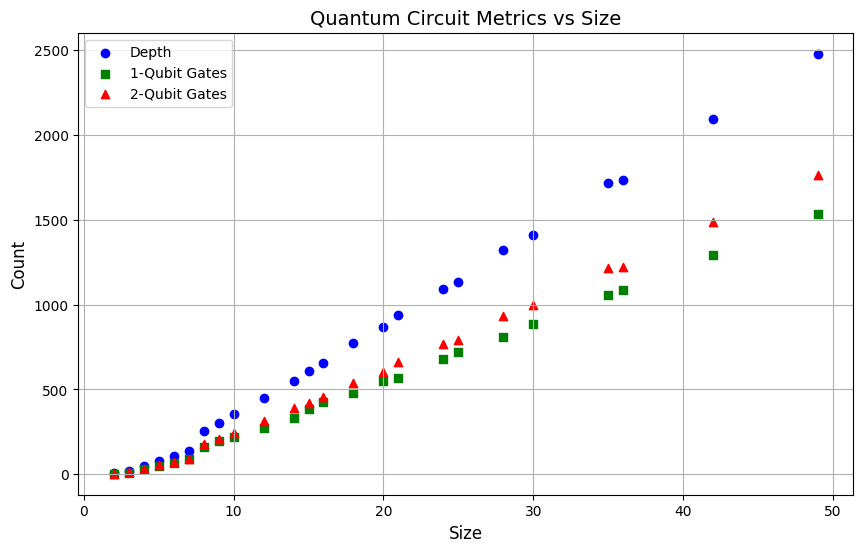

In [31]:
import matplotlib.pyplot as plt

# Extract data from the dictionary
x = res['size']
y1 = res['dept']
y2 = res['1qgates']
y3 = res['2qgates']

# Create the plot
plt.figure(figsize=(10, 6))

# Plot each line with different colors and linestyles
plt.scatter(x, y1, label='Depth', color='blue',  marker='o')
plt.scatter(x, y2, label='1-Qubit Gates', color='green', marker='s')
plt.scatter(x, y3, label='2-Qubit Gates', color='red',  marker='^')

# Add labels, legend, and grid
plt.xlabel('Size', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Quantum Circuit Metrics vs Size', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True)

# Show the plot
plt.show()

# Done
I hope you learnt something from this demo! 